# DSC 241 Project Notebook  
## Real Estate Valuation: Explanation, Prediction, and Robustness Analysis



### Research questions
- **RQ1.** Which variables are statistically associated with house price per unit area?
- **RQ2.** Do nonlinear transformations and feature engineering materially improve fit over a naive linear specification?
- **RQ3.** How much predictive power is contained in accessibility and spatial information?
- **RQ4.** How do interpretable regression models compare with tree-based models and a neural network out of sample?
- **RQ5.** Where do models fail, and are conclusions robust to influential observations and alternative response transformations?

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RepeatedKFold, cross_validate, cross_val_predict
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 241
np.random.seed(RANDOM_STATE)

CV_REPEATS = 3
RF_TREES = 300
GBR_ITERS = 250
MLP_MAX_ITER = 2500

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "Real estate valuation data set.xlsx"
OUTPUT_ROOT = PROJECT_ROOT / "real_estate_project_outputs"
FIG_DIR = OUTPUT_ROOT / "latex_figures"
TABLE_DIR = OUTPUT_ROOT / "latex_tables"
TXT_DIR = OUTPUT_ROOT / "latex_text"

for p in [OUTPUT_ROOT, FIG_DIR, TABLE_DIR, TXT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

In [ ]:
def savefig(name, dpi=300, bbox_inches="tight"):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=dpi, bbox_inches=bbox_inches)
    print(f"Saved figure -> {path}")
    return path

def export_table(df, stem, index=False, float_fmt="%.4f"):
    csv_path = TABLE_DIR / f"{stem}.csv"
    tex_path = TABLE_DIR / f"{stem}.tex"
    df.to_csv(csv_path, index=index)
    latex = df.to_latex(index=index, escape=False, float_format=lambda x: float_fmt % x if isinstance(x, (int, float, np.floating)) else x)
    tex_path.write_text(latex, encoding="utf-8")
    print(f"Saved table -> {csv_path}")
    print(f"Saved table -> {tex_path}")
    return csv_path, tex_path

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def summarize_cv(cv_dict):
    rows = []
    for model_name, scores in cv_dict.items():
        rows.append({
            "model": model_name,
            "rmse_mean": -scores["test_rmse"].mean(),
            "rmse_sd": scores["test_rmse"].std(),
            "mae_mean": -scores["test_mae"].mean(),
            "mae_sd": scores["test_mae"].std(),
            "r2_mean": scores["test_r2"].mean(),
            "r2_sd": scores["test_r2"].std(),
        })
    return pd.DataFrame(rows).sort_values(["rmse_mean", "r2_mean"], ascending=[True, False]).reset_index(drop=True)

def add_lowess(ax, x, y, frac=0.6, color="black", label="LOWESS"):
    fitted = lowess(y, x, frac=frac, return_sorted=True)
    ax.plot(fitted[:, 0], fitted[:, 1], lw=2.2, color=color, label=label)
    return ax

def out_of_fold_metrics(y_true, y_pred):
    return {"RMSE": rmse(y_true, y_pred), "MAE": mean_absolute_error(y_true, y_pred), "R2": r2_score(y_true, y_pred)}

In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Cannot find {DATA_PATH.name}. Put the Excel file in the same folder as this notebook, or update DATA_PATH.")
raw_df = pd.read_excel(DATA_PATH)
rename_map = {
    "No": "id",
    "X1 transaction date": "transaction_date",
    "X2 house age": "house_age",
    "X3 distance to the nearest MRT station": "distance_mrt",
    "X4 number of convenience stores": "stores",
    "X5 latitude": "latitude",
    "X6 longitude": "longitude",
    "Y house price of unit area": "price",
}
df = raw_df.rename(columns=rename_map).copy()
quality = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_n": df.isna().sum().values,
    "missing_pct": (df.isna().mean().values * 100).round(2),
    "n_unique": df.nunique().values
})
display(quality)
export_table(quality, "data_quality_summary", index=False)

desc = df.drop(columns=["id"]).describe().T
desc["skew"] = df.drop(columns=["id"]).skew()
desc["kurtosis"] = df.drop(columns=["id"]).kurtosis()
display(desc)
export_table(desc.reset_index().rename(columns={"index": "variable"}), "descriptive_statistics", index=False)

,variable,dtype,missing_n,missing_pct,n_unique
0,id,int64,0,0.0,414
1,transaction_date,float64,0,0.0,12
2,house_age,float64,0,0.0,236
3,distance_mrt,float64,0,0.0,259
4,stores,int64,0,0.0,11
5,latitude,float64,0,0.0,234
6,longitude,float64,0,0.0,232
7,price,float64,0,0.0,270


Saved table -> /content/real_estate_project_outputs/latex_tables/data_quality_summary.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/data_quality_summary.tex


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
transaction_date,414.0,2013.148953,0.281995,2012.666667,2012.916667,2013.166667,2013.416667,2013.583333,-0.150834,-1.231946
house_age,414.0,17.712560,11.392485,0.000000,9.025000,16.100000,28.150000,43.800000,0.382926,-0.877120
distance_mrt,414.0,1083.885689,1262.109595,23.382840,289.324800,492.231300,1454.279000,6488.021000,1.888757,3.207868
stores,414.0,4.094203,2.945562,0.000000,1.000000,4.000000,6.000000,10.000000,0.154607,-1.065751
latitude,414.0,24.969030,0.012410,24.932070,24.963000,24.971100,24.977455,25.014590,-0.438598,0.269070
longitude,414.0,121.533361,0.015347,121.473530,121.528085,121.538630,121.543305,121.566270,-1.219591,1.201792
price,414.0,37.980193,13.606488,7.600000,27.700000,38.450000,46.600000,117.500000,0.599853,2.179097


Saved table -> /content/real_estate_project_outputs/latex_tables/descriptive_statistics.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/descriptive_statistics.tex


(PosixPath('/content/real_estate_project_outputs/latex_tables/descriptive_statistics.csv'),
 PosixPath('/content/real_estate_project_outputs/latex_tables/descriptive_statistics.tex'))

In [ ]:
work = df.copy()
work["log_price"] = np.log(work["price"])
work["log_dist"] = np.log1p(work["distance_mrt"])
work["age_sq"] = work["house_age"] ** 2
work["stores_sq"] = work["stores"] ** 2
work["lat_sq"] = work["latitude"] ** 2
work["lon_sq"] = work["longitude"] ** 2
work["lat_lon"] = work["latitude"] * work["longitude"]
work["date_centered"] = work["transaction_date"] - work["transaction_date"].mean()
geo_kmeans = KMeans(n_clusters=3, n_init=25, random_state=RANDOM_STATE)
work["geo_cluster"] = geo_kmeans.fit_predict(work[["latitude", "longitude"]]).astype(str)
work.head()

,id,transaction_date,house_age,distance_mrt,stores,latitude,longitude,price,log_price,log_dist,age_sq,stores_sq,lat_sq,lon_sq,lat_lon,date_centered,geo_cluster
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,3.634951,4.452937,1024.00,100,624.149290,14772.029939,3036.437385,-0.232287,0
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,3.742420,5.728783,380.25,81,624.017387,14771.852491,3036.098283,-0.232287,0
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,3.856510,6.333252,176.89,25,624.373157,14772.922058,3037.073589,0.434380,0
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,4.003690,6.333252,176.89,25,624.373157,14772.922058,3037.073589,0.351047,0
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,3.763523,5.970160,25.00,25,623.968926,14772.567152,3036.053829,-0.315620,0


Saved figure -> /content/real_estate_project_outputs/latex_figures/fig01_price_distribution.png


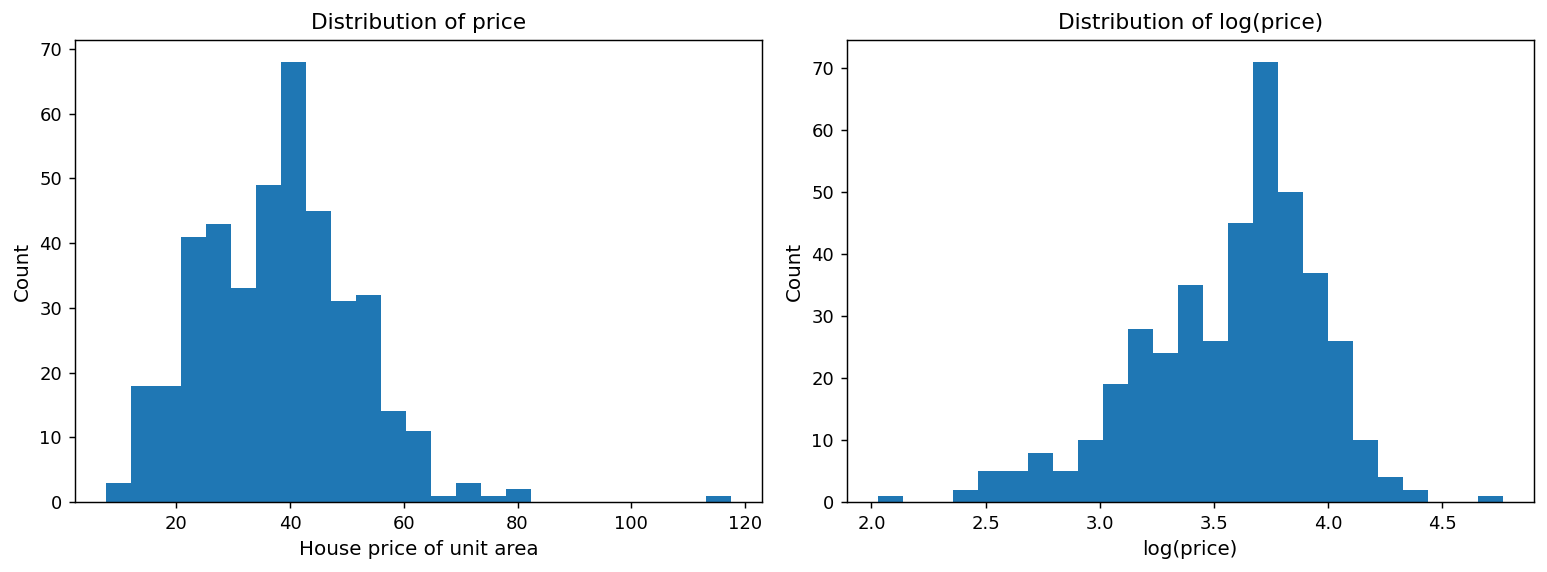

Saved figure -> /content/real_estate_project_outputs/latex_figures/fig02_price_vs_distance.png


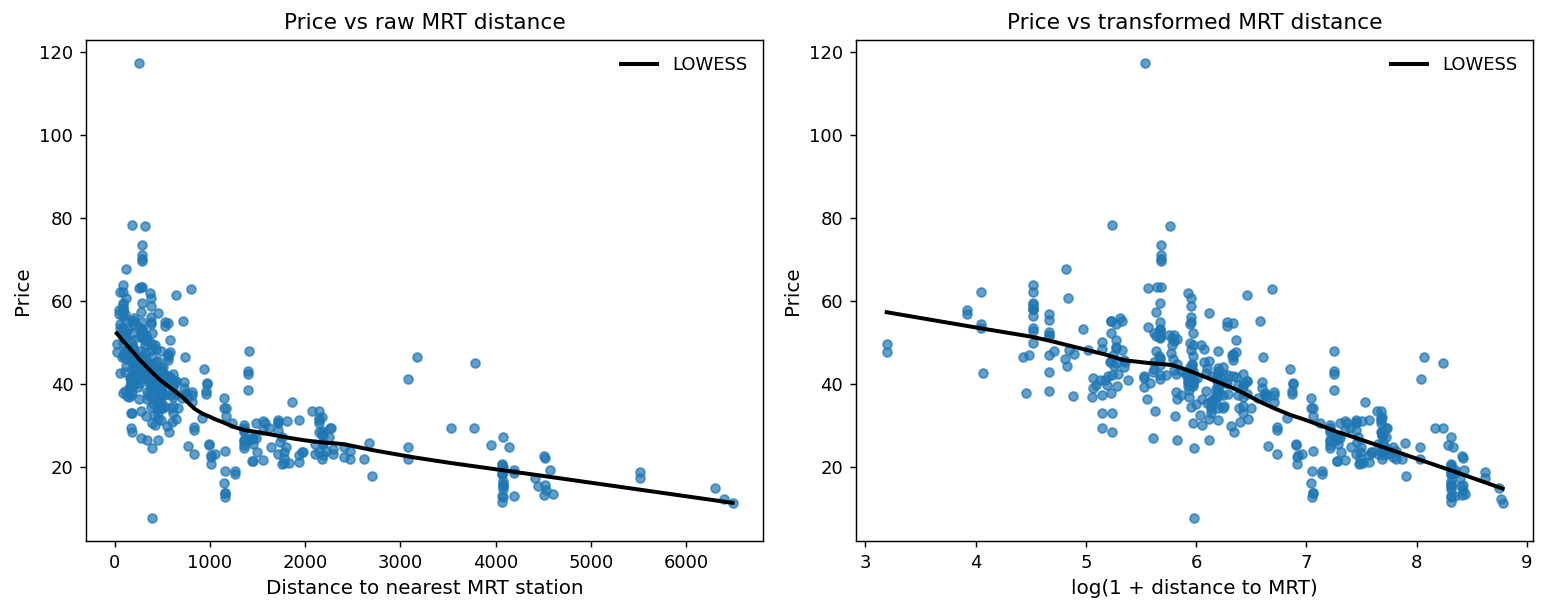

Saved figure -> /content/real_estate_project_outputs/latex_figures/fig03_price_vs_age_stores.png


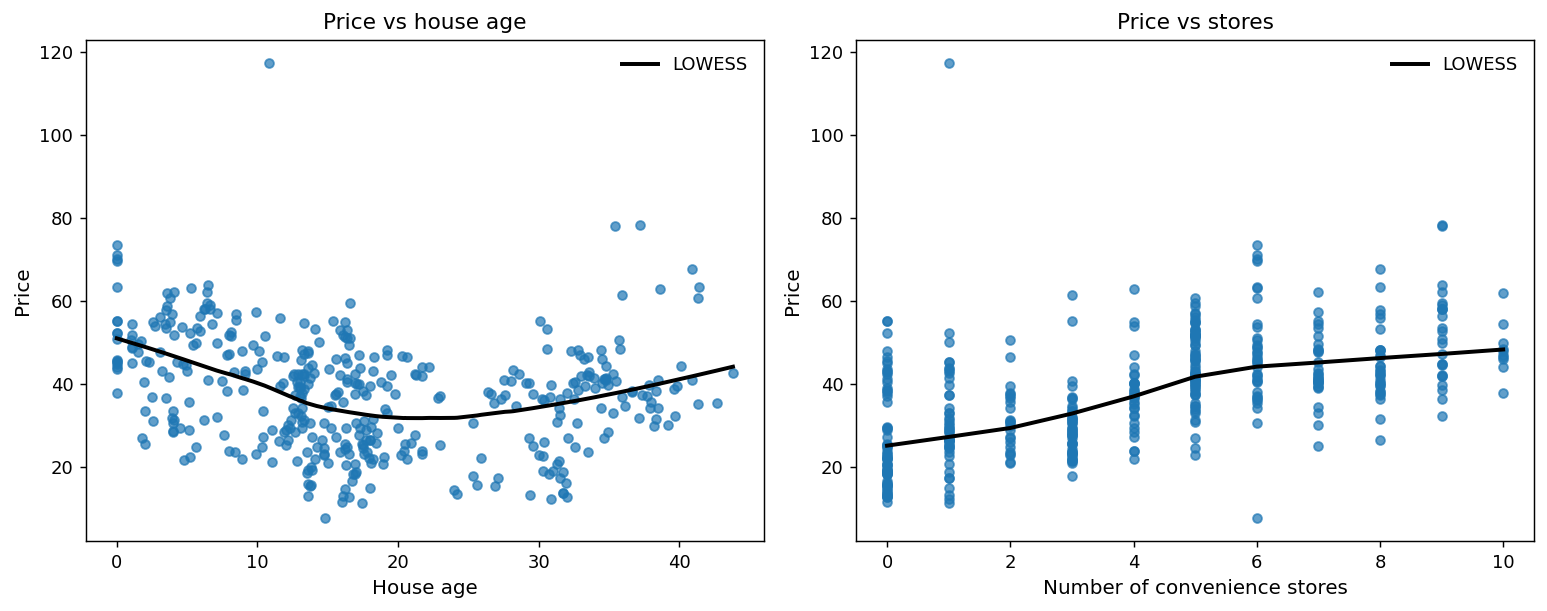

Saved figure -> /content/real_estate_project_outputs/latex_figures/fig04_spatial_price_map.png


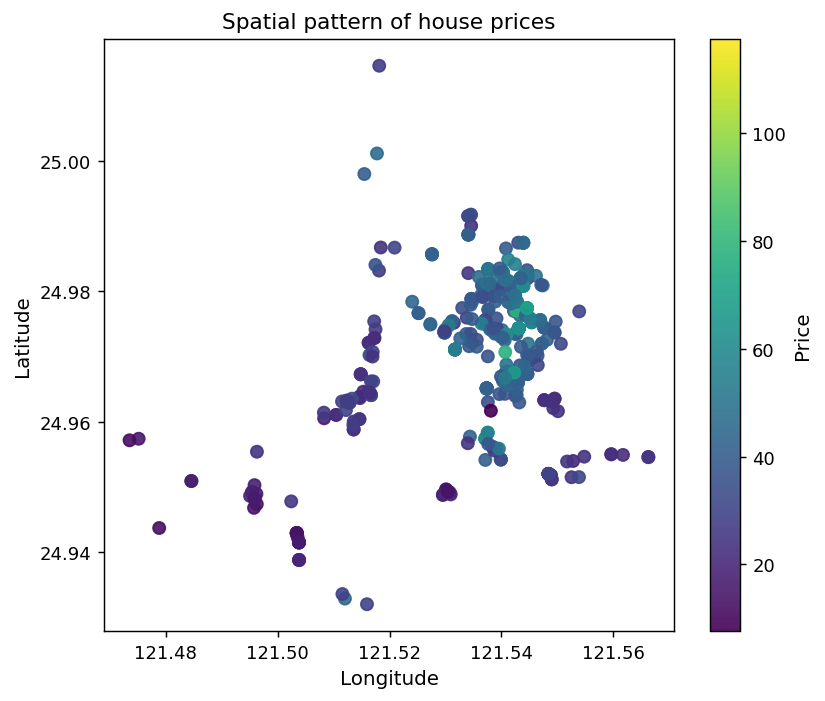

Saved figure -> /content/real_estate_project_outputs/latex_figures/fig05_correlation_matrix.png


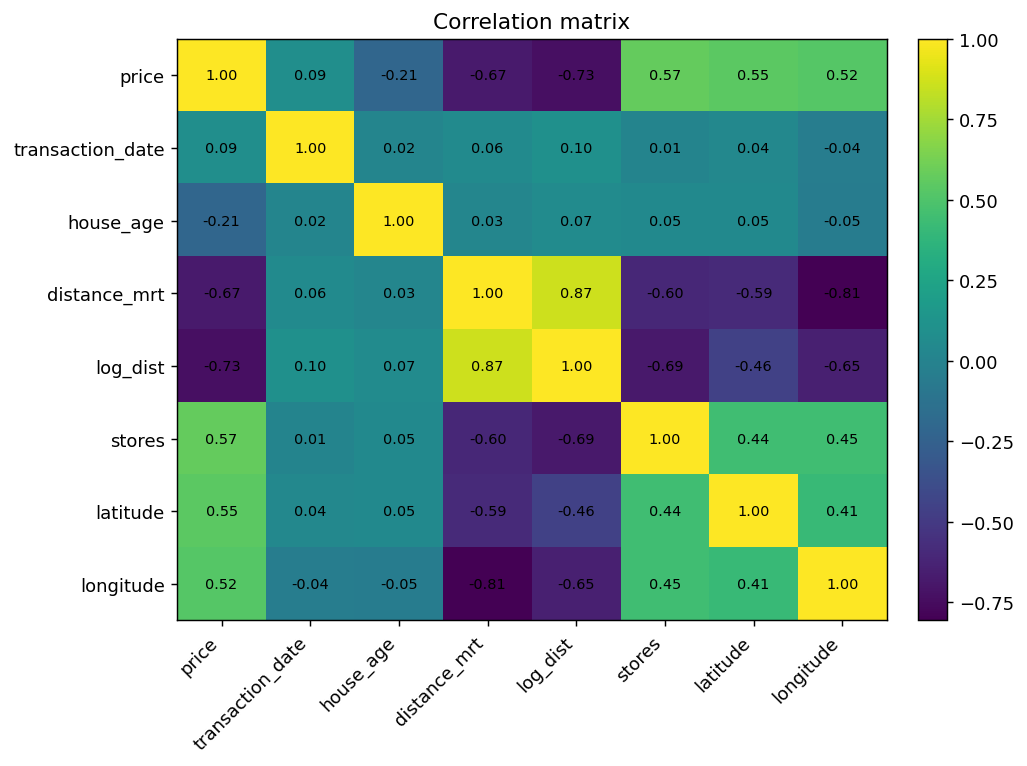

Saved table -> /content/real_estate_project_outputs/latex_tables/correlation_matrix.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/correlation_matrix.tex


,geo_cluster,n,mean_price,median_price,mean_distance,mean_stores
0,0,205,45.214,43.10,509.694,4.907
2,2,121,36.527,37.40,675.006,4.364
1,1,88,23.127,23.05,2983.701,1.830


Saved table -> /content/real_estate_project_outputs/latex_tables/geo_cluster_summary.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/geo_cluster_summary.tex


(PosixPath('/content/real_estate_project_outputs/latex_tables/geo_cluster_summary.csv'),
 PosixPath('/content/real_estate_project_outputs/latex_tables/geo_cluster_summary.tex'))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(work["price"], bins=25)
axes[0].set_title("Distribution of price")
axes[0].set_xlabel("House price of unit area"); axes[0].set_ylabel("Count")
axes[1].hist(work["log_price"], bins=25)
axes[1].set_title("Distribution of log(price)")
axes[1].set_xlabel("log(price)"); axes[1].set_ylabel("Count")
plt.tight_layout(); savefig("fig01_price_distribution"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(work["distance_mrt"], work["price"], alpha=0.7, s=24)
axes[0].set_xlabel("Distance to nearest MRT station"); axes[0].set_ylabel("Price"); axes[0].set_title("Price vs raw MRT distance"); add_lowess(axes[0], work["distance_mrt"], work["price"], frac=0.5)
axes[1].scatter(work["log_dist"], work["price"], alpha=0.7, s=24)
axes[1].set_xlabel("log(1 + distance to MRT)"); axes[1].set_ylabel("Price"); axes[1].set_title("Price vs transformed MRT distance"); add_lowess(axes[1], work["log_dist"], work["price"], frac=0.5)
for ax in axes: ax.legend(frameon=False)
plt.tight_layout(); savefig("fig02_price_vs_distance"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(work["house_age"], work["price"], alpha=0.7, s=24)
axes[0].set_xlabel("House age"); axes[0].set_ylabel("Price"); axes[0].set_title("Price vs house age"); add_lowess(axes[0], work["house_age"], work["price"], frac=0.55)
axes[1].scatter(work["stores"], work["price"], alpha=0.7, s=24)
axes[1].set_xlabel("Number of convenience stores"); axes[1].set_ylabel("Price"); axes[1].set_title("Price vs stores"); add_lowess(axes[1], work["stores"], work["price"], frac=0.6)
for ax in axes: ax.legend(frameon=False)
plt.tight_layout(); savefig("fig03_price_vs_age_stores"); plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(work["longitude"], work["latitude"], c=work["price"], s=45, alpha=0.9)
ax.set_title("Spatial pattern of house prices"); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax).set_label("Price")
plt.tight_layout(); savefig("fig04_spatial_price_map"); plt.show()

corr = work[["price","transaction_date","house_age","distance_mrt","log_dist","stores","latitude","longitude"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right"); ax.set_yticklabels(corr.index); ax.set_title("Correlation matrix")
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); savefig("fig05_correlation_matrix"); plt.show()
export_table(corr.reset_index().rename(columns={"index": "variable"}), "correlation_matrix", index=False)

cluster_summary = (work.groupby("geo_cluster")
                   .agg(n=("price","size"), mean_price=("price","mean"), median_price=("price","median"),
                        mean_distance=("distance_mrt","mean"), mean_stores=("stores","mean"))
                   .round(3).reset_index().sort_values("mean_price", ascending=False))
display(cluster_summary); export_table(cluster_summary, "geo_cluster_summary", index=False)

In [ ]:
formula_raw = "price ~ transaction_date + house_age + age_sq + log_dist + stores + latitude + longitude + lat_lon"
formula_log = "log_price ~ transaction_date + house_age + age_sq + log_dist + stores + latitude + longitude + lat_lon"
ols_raw = smf.ols(formula_raw, data=work).fit()
ols_log = smf.ols(formula_log, data=work).fit()
print(ols_raw.summary())
print(ols_log.summary())

coef_raw = ols_raw.summary2().tables[1].reset_index().rename(columns={"index":"term"})
coef_log = ols_log.summary2().tables[1].reset_index().rename(columns={"index":"term"})
export_table(coef_raw, "coef_table_ols_raw", index=False)
export_table(coef_log, "coef_table_ols_log", index=False)
(TXT_DIR / "ols_raw_summary.txt").write_text(ols_raw.summary().as_text(), encoding="utf-8")
(TXT_DIR / "ols_log_summary.txt").write_text(ols_log.summary().as_text(), encoding="utf-8")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     111.2
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           2.93e-97
Time:                        22:33:26   Log-Likelihood:                -1427.1
No. Observations:                 414   AIC:                             2872.
Df Residuals:                     405   BIC:                             2909.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          3.04e+07   6.73e+06  

2610

Saved figure -> /content/real_estate_project_outputs/latex_figures/fig06_regression_diagnostics.png


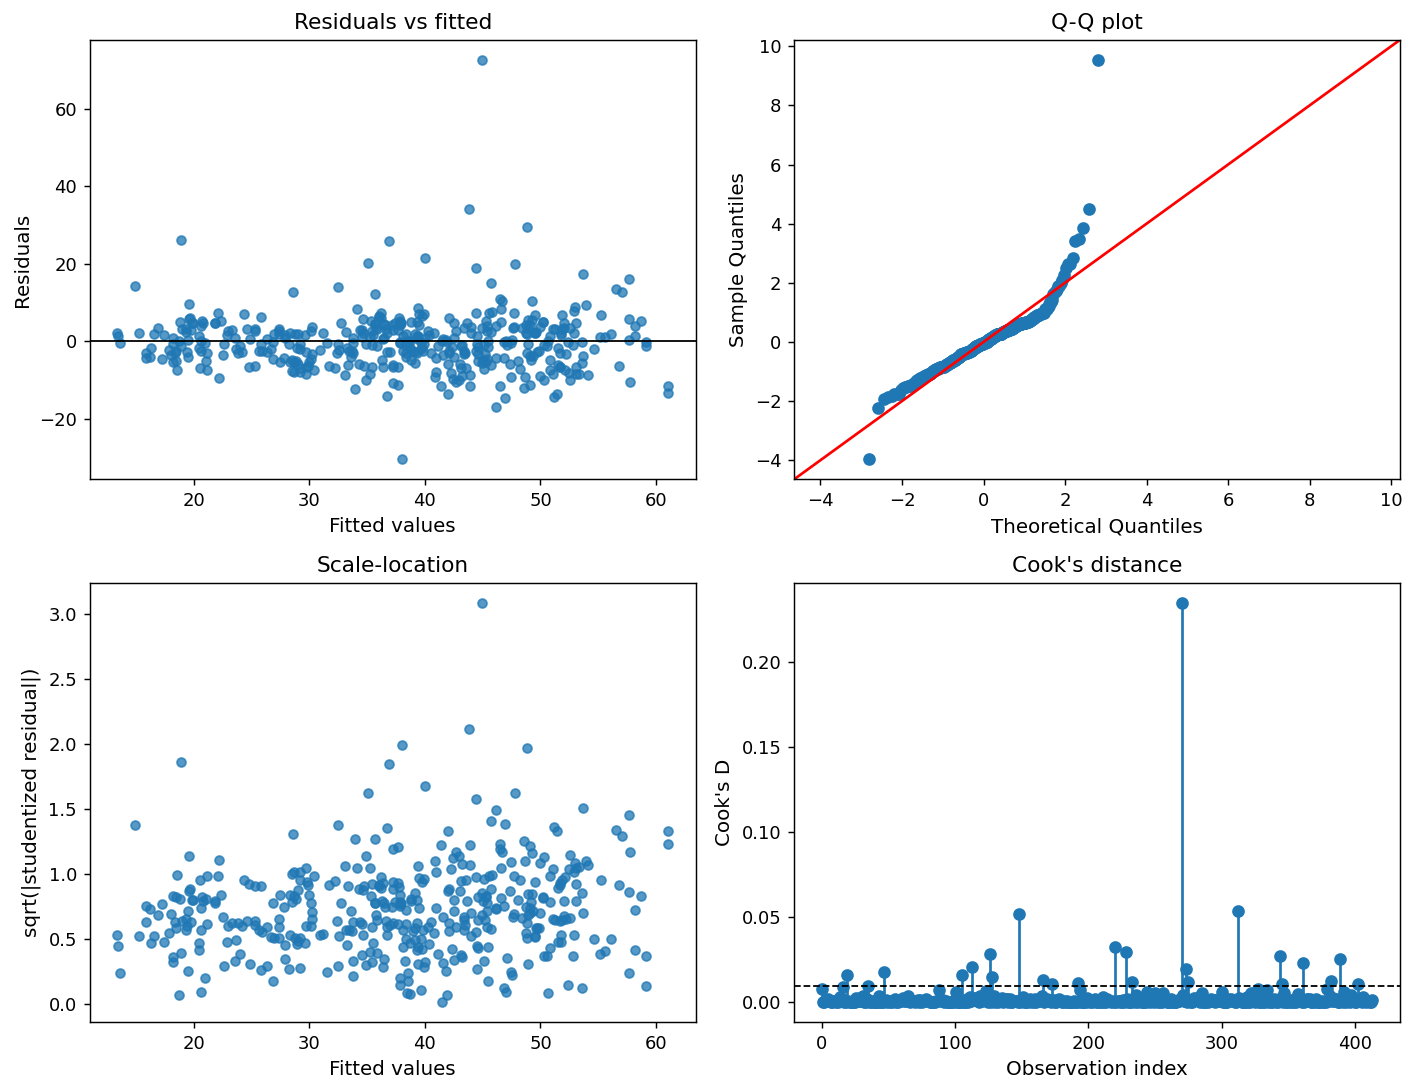

,variable,VIF
0,const,3.216857e+14
1,transaction_date,1.027100e+00
2,house_age,1.625970e+01
3,age_sq,1.610280e+01
4,log_dist,2.977900e+00
5,stores,2.108700e+00
6,latitude,7.828898e+07
7,longitude,5.049603e+06
8,lat_lon,9.976249e+07


Saved table -> /content/real_estate_project_outputs/latex_tables/vif_table.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/vif_table.tex


,id,fitted,residual,studentized_resid,leverage,cooks_d
270,271,44.942796,72.557204,9.550240,0.022666,0.235027
312,313,43.853342,34.146658,4.495973,0.023304,0.053588
148,149,18.895792,26.204208,3.474880,0.037118,0.051719
220,221,48.828444,29.471556,3.872019,0.019062,0.032371
228,229,32.490653,14.109347,1.901867,0.068112,0.029375
126,127,36.915862,25.984138,3.418116,0.021516,0.028546
344,345,28.572137,12.627863,1.710440,0.077100,0.027156
389,390,47.798944,19.901056,2.632343,0.032218,0.025631
361,362,44.396209,18.903791,2.499963,0.031853,0.022847
113,114,37.984799,-30.384799,-3.977060,0.011677,0.020764


Saved table -> /content/real_estate_project_outputs/latex_tables/high_influence_points.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/high_influence_points.tex


(PosixPath('/content/real_estate_project_outputs/latex_tables/high_influence_points.csv'),
 PosixPath('/content/real_estate_project_outputs/latex_tables/high_influence_points.tex'))

In [ ]:
fitted = ols_raw.fittedvalues
resid = ols_raw.resid
student_resid = ols_raw.get_influence().resid_studentized_internal

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
axes[0, 0].scatter(fitted, resid, alpha=0.75, s=24); axes[0, 0].axhline(0, color="black", lw=1)
axes[0, 0].set_title("Residuals vs fitted"); axes[0, 0].set_xlabel("Fitted values"); axes[0, 0].set_ylabel("Residuals")
qqplot(student_resid, line="45", ax=axes[0, 1], fit=True); axes[0, 1].set_title("Q-Q plot")
axes[1, 0].scatter(fitted, np.sqrt(np.abs(student_resid)), alpha=0.75, s=24)
axes[1, 0].set_title("Scale-location"); axes[1, 0].set_xlabel("Fitted values"); axes[1, 0].set_ylabel("sqrt(|studentized residual|)")
cooks = ols_raw.get_influence().cooks_distance[0]
axes[1, 1].stem(np.arange(len(cooks)), cooks, basefmt=" "); axes[1, 1].axhline(4 / len(work), color="black", ls="--", lw=1)
axes[1, 1].set_title("Cook's distance"); axes[1, 1].set_xlabel("Observation index"); axes[1, 1].set_ylabel("Cook's D")
plt.tight_layout(); savefig("fig06_regression_diagnostics"); plt.show()

X_vif = sm.add_constant(work[["transaction_date","house_age","age_sq","log_dist","stores","latitude","longitude","lat_lon"]])
vif_df = pd.DataFrame({"variable": X_vif.columns, "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])] }).round(4)
display(vif_df); export_table(vif_df, "vif_table", index=False)

influence = ols_raw.get_influence()
influence_df = pd.DataFrame({
    "id": work["id"], "fitted": ols_raw.fittedvalues, "residual": ols_raw.resid,
    "studentized_resid": influence.resid_studentized_internal,
    "leverage": influence.hat_matrix_diag, "cooks_d": influence.cooks_distance[0]
})
cook_threshold = 4 / len(work)
high_influence = influence_df.loc[influence_df["cooks_d"] > cook_threshold].sort_values("cooks_d", ascending=False)
display(high_influence.head(15)); export_table(high_influence, "high_influence_points", index=False)

Finished: OLS_baseline
Finished: OLS_engineered
Finished: Ridge_engineered
Finished: Lasso_engineered
Finished: Spline_linear
Finished: Random_forest
Finished: Gradient_boosting
Finished: MLP_neural_net


,model,rmse_mean,rmse_sd,mae_mean,mae_sd,r2_mean,r2_sd
0,Random_forest,7.401200,1.592335,4.842123,0.509019,0.698447,0.071004
1,Gradient_boosting,7.700159,1.548391,5.094178,0.485951,0.674443,0.064180
2,Spline_linear,7.765119,1.542088,5.106042,0.556768,0.667373,0.074079
3,OLS_engineered,7.794483,1.543340,5.315166,0.538116,0.665904,0.067327
4,Lasso_engineered,7.935105,1.563446,5.323121,0.623400,0.653073,0.073014
5,Ridge_engineered,7.939613,1.562287,5.324639,0.624119,0.652640,0.073079
6,MLP_neural_net,8.696083,1.964819,6.099040,1.411940,0.576687,0.150734
7,OLS_baseline,8.878194,1.629284,6.323629,0.763923,0.565694,0.079738


Saved table -> /content/real_estate_project_outputs/latex_tables/cv_model_comparison.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/cv_model_comparison.tex
Saved figure -> /content/real_estate_project_outputs/latex_figures/fig07_cv_rmse_comparison.png


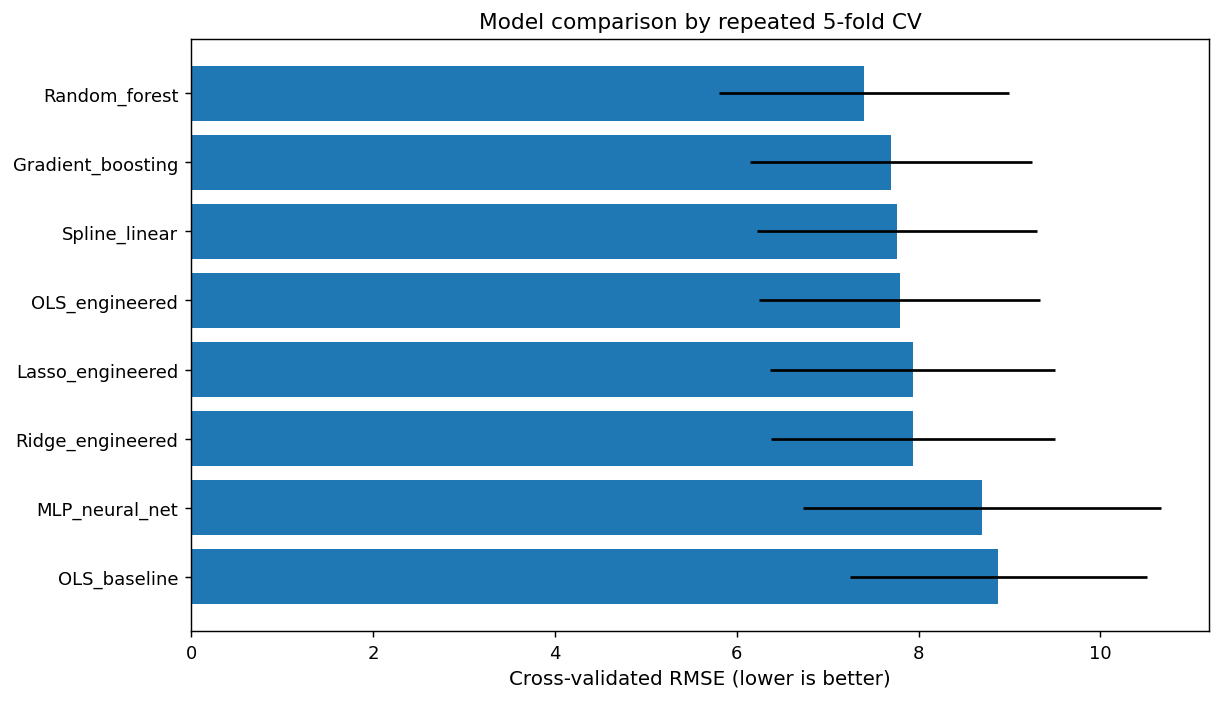

Saved figure -> /content/real_estate_project_outputs/latex_figures/fig08_cv_r2_comparison.png


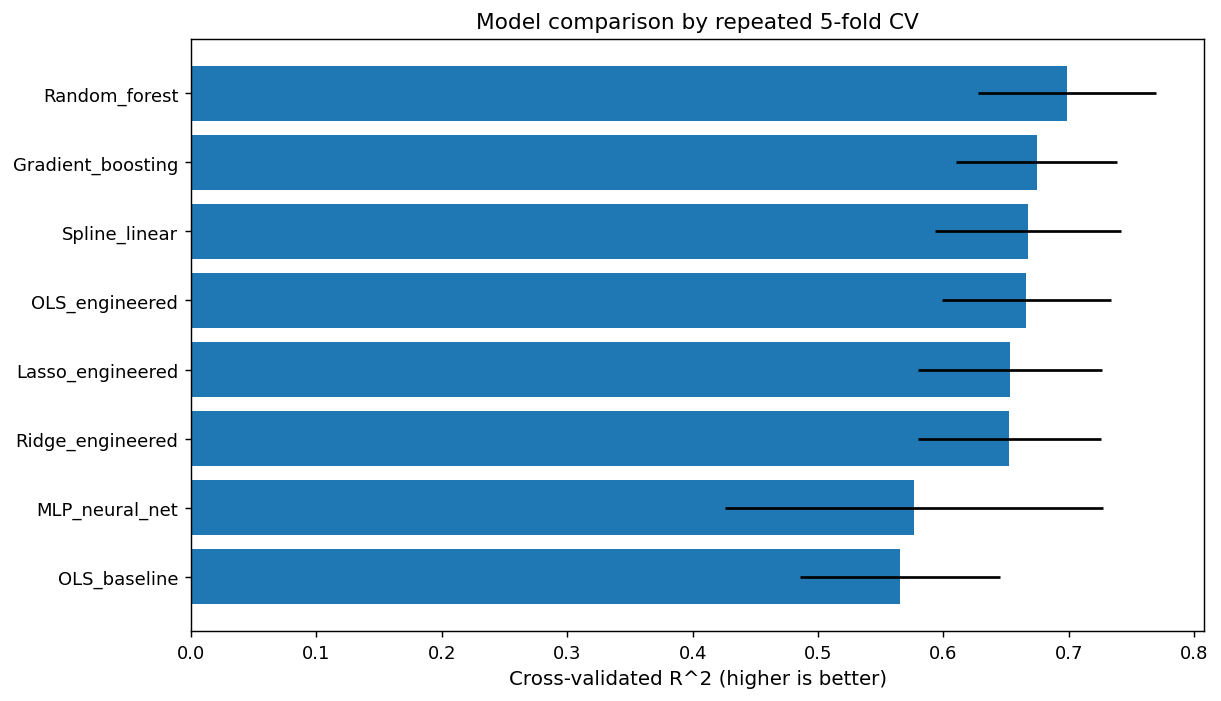

In [ ]:
base_features = ["transaction_date","house_age","distance_mrt","stores","latitude","longitude"]
engineered_features = ["transaction_date","house_age","log_dist","stores","latitude","longitude","age_sq","lat_sq","lon_sq","lat_lon"]
X_base = work[base_features].copy(); X_eng = work[engineered_features].copy(); y = work["price"].copy()

cv = RepeatedKFold(n_splits=5, n_repeats=CV_REPEATS, random_state=RANDOM_STATE)
scoring = {"rmse":"neg_root_mean_squared_error","mae":"neg_mean_absolute_error","r2":"r2"}

linear_base = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", LinearRegression())])
linear_eng = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", LinearRegression())])
ridge_eng = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", RidgeCV(alphas=np.logspace(-3, 3, 25)))])
lasso_eng = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LassoCV(cv=5, max_iter=20000, random_state=RANDOM_STATE))])

spline_pre = ColumnTransformer(transformers=[
    ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False), ["house_age","log_dist","latitude","longitude"]),
    ("pass", "passthrough", ["transaction_date","stores"])
], remainder="drop")
spline_linear = Pipeline([("features", spline_pre), ("model", LinearRegression())])

rf_model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestRegressor(n_estimators=RF_TREES, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1))])
gbr_model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", HistGradientBoostingRegressor(learning_rate=0.04, max_depth=4, max_iter=GBR_ITERS, min_samples_leaf=10, random_state=RANDOM_STATE))])
mlp_model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", MLPRegressor(hidden_layer_sizes=(64,32), activation="relu", alpha=0.001, learning_rate_init=0.003, max_iter=MLP_MAX_ITER, early_stopping=True, random_state=RANDOM_STATE))])

models = {
    "OLS_baseline": (linear_base, X_base),
    "OLS_engineered": (linear_eng, X_eng),
    "Ridge_engineered": (ridge_eng, X_eng),
    "Lasso_engineered": (lasso_eng, X_eng),
    "Spline_linear": (spline_linear, X_eng[["transaction_date","house_age","log_dist","stores","latitude","longitude"]]),
    "Random_forest": (rf_model, X_eng),
    "Gradient_boosting": (gbr_model, X_eng),
    "MLP_neural_net": (mlp_model, X_eng),
}
cv_scores = {}
for name, (model, Xmat) in models.items():
    scores = cross_validate(model, Xmat, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_scores[name] = scores
    print(f"Finished: {name}")

cv_results = summarize_cv(cv_scores)
display(cv_results); export_table(cv_results, "cv_model_comparison", index=False)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
order = cv_results.sort_values("rmse_mean", ascending=False)
ax.barh(order["model"], order["rmse_mean"], xerr=order["rmse_sd"])
ax.set_xlabel("Cross-validated RMSE (lower is better)"); ax.set_title("Model comparison by repeated 5-fold CV")
plt.tight_layout(); savefig("fig07_cv_rmse_comparison"); plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.5))
order = cv_results.sort_values("r2_mean", ascending=True)
ax.barh(order["model"], order["r2_mean"], xerr=order["r2_sd"])
ax.set_xlabel("Cross-validated R^2 (higher is better)"); ax.set_title("Model comparison by repeated 5-fold CV")
plt.tight_layout(); savefig("fig08_cv_r2_comparison"); plt.show()

,RMSE,MAE,R2,model
0,7.523044,4.791708,0.693560,Random_forest
1,7.914012,5.095649,0.660881,Gradient_boosting
2,7.924389,5.331342,0.659992,OLS_engineered
3,8.796512,5.982467,0.581034,MLP_neural_net
4,9.065233,6.329969,0.555045,OLS_baseline


Saved table -> /content/real_estate_project_outputs/latex_tables/oof_metrics.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/oof_metrics.tex
Saved figure -> /content/real_estate_project_outputs/latex_figures/fig09_best_model_oof_diagnostics.png


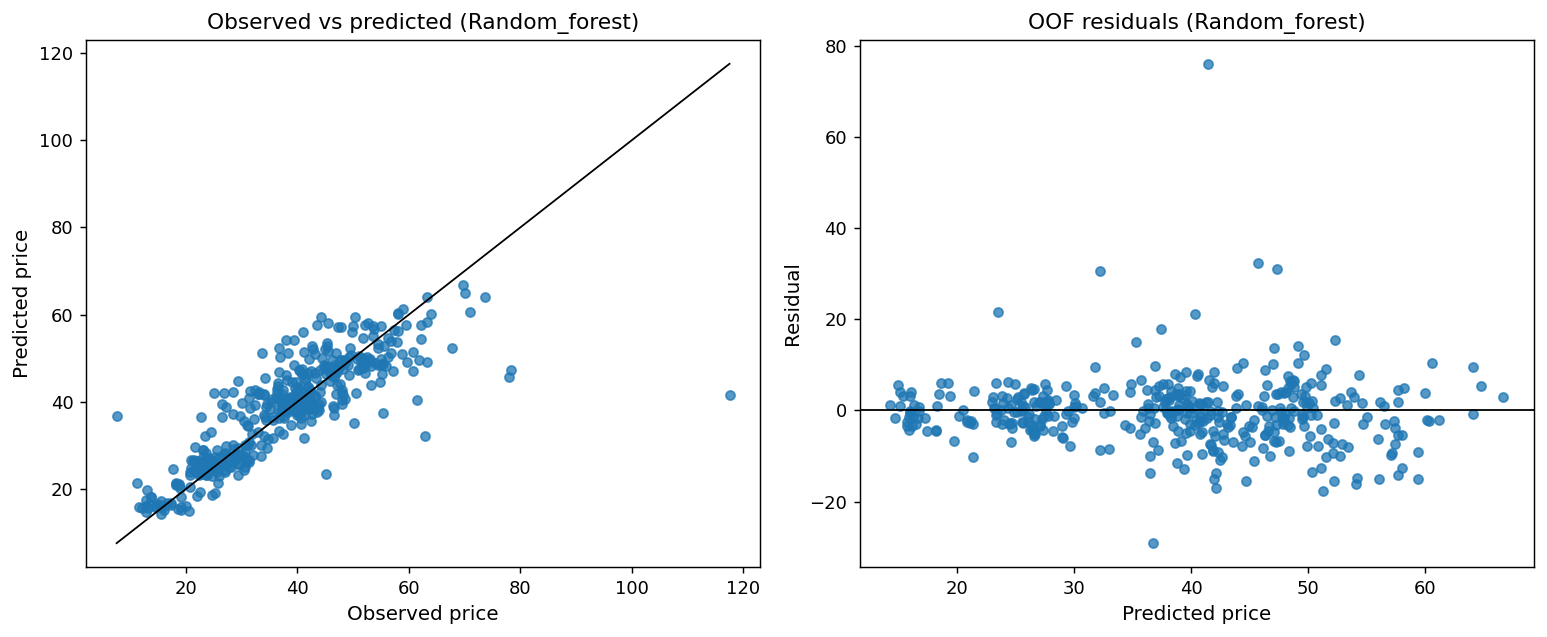

In [ ]:
oof_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
selected_oof = {
    "OLS_baseline": (linear_base, X_base),
    "OLS_engineered": (linear_eng, X_eng),
    "Random_forest": (rf_model, X_eng),
    "Gradient_boosting": (gbr_model, X_eng),
    "MLP_neural_net": (mlp_model, X_eng),
}
oof_df = work[["id","price","distance_mrt","log_dist","house_age","stores","latitude","longitude","geo_cluster"]].copy()
for name, (model, Xmat) in selected_oof.items():
    preds = cross_val_predict(model, Xmat, y, cv=oof_cv, n_jobs=-1)
    oof_df[f"pred_{name}"] = preds
    oof_df[f"abs_err_{name}"] = np.abs(oof_df["price"] - preds)
    oof_df[f"sq_err_{name}"] = (oof_df["price"] - preds) ** 2

oof_metrics = []
for name in selected_oof.keys():
    m = out_of_fold_metrics(oof_df["price"], oof_df[f"pred_{name}"]); m["model"] = name; oof_metrics.append(m)
oof_metrics = pd.DataFrame(oof_metrics).sort_values("RMSE").reset_index(drop=True)
display(oof_metrics); export_table(oof_metrics, "oof_metrics", index=False)

best_oof = oof_metrics.iloc[0]["model"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
mn = min(oof_df["price"].min(), oof_df[f"pred_{best_oof}"].min()); mx = max(oof_df["price"].max(), oof_df[f"pred_{best_oof}"].max())
axes[0].scatter(oof_df["price"], oof_df[f"pred_{best_oof}"], alpha=0.75, s=25); axes[0].plot([mn, mx], [mn, mx], color="black", lw=1)
axes[0].set_xlabel("Observed price"); axes[0].set_ylabel("Predicted price"); axes[0].set_title(f"Observed vs predicted ({best_oof})")
axes[1].scatter(oof_df[f"pred_{best_oof}"], oof_df["price"] - oof_df[f"pred_{best_oof}"], alpha=0.75, s=25); axes[1].axhline(0, color="black", lw=1)
axes[1].set_xlabel("Predicted price"); axes[1].set_ylabel("Residual"); axes[1].set_title(f"OOF residuals ({best_oof})")
plt.tight_layout(); savefig("fig09_best_model_oof_diagnostics"); plt.show()

,feature,importance_mean,importance_sd,model
12,log_dist,0.836869,0.054306,Gradient_boosting
11,house_age,0.206547,0.019502,Gradient_boosting
14,latitude,0.090294,0.009421,Gradient_boosting
10,transaction_date,0.057870,0.006843,Gradient_boosting
19,lat_lon,0.045645,0.003966,Gradient_boosting
15,longitude,0.045550,0.004413,Gradient_boosting
13,stores,0.015228,0.001813,Gradient_boosting
16,age_sq,0.000000,0.000000,Gradient_boosting
17,lat_sq,0.000000,0.000000,Gradient_boosting
18,lon_sq,0.000000,0.000000,Gradient_boosting


Saved table -> /content/real_estate_project_outputs/latex_tables/permutation_importance.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/permutation_importance.tex
Saved figure -> /content/real_estate_project_outputs/latex_figures/fig10_permutation_importance_gbr.png


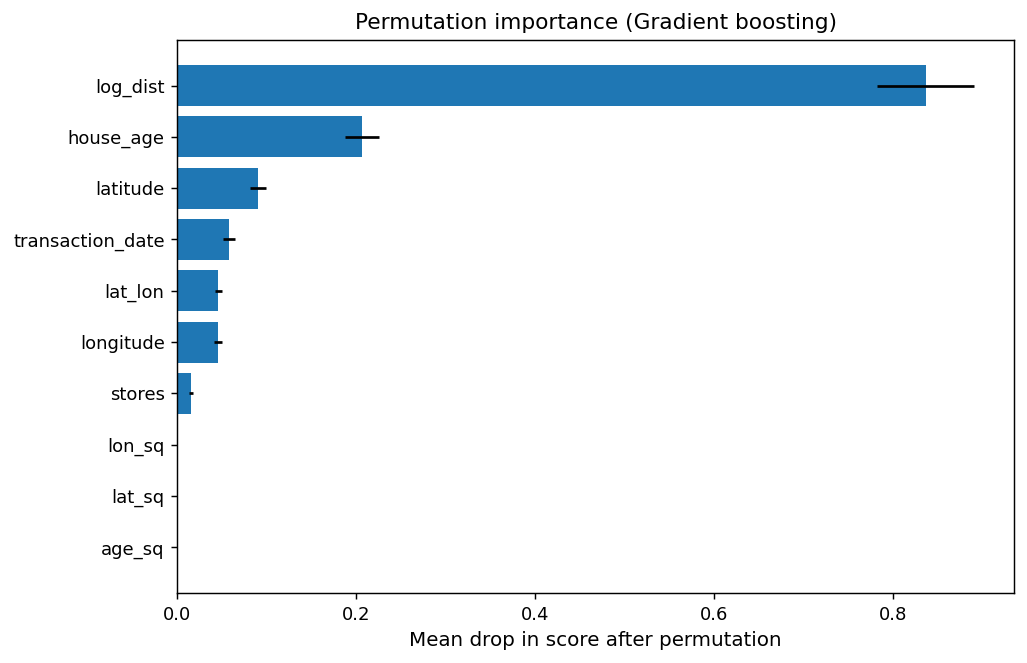

Saved figure -> /content/real_estate_project_outputs/latex_figures/fig11_partial_dependence_gbr.png


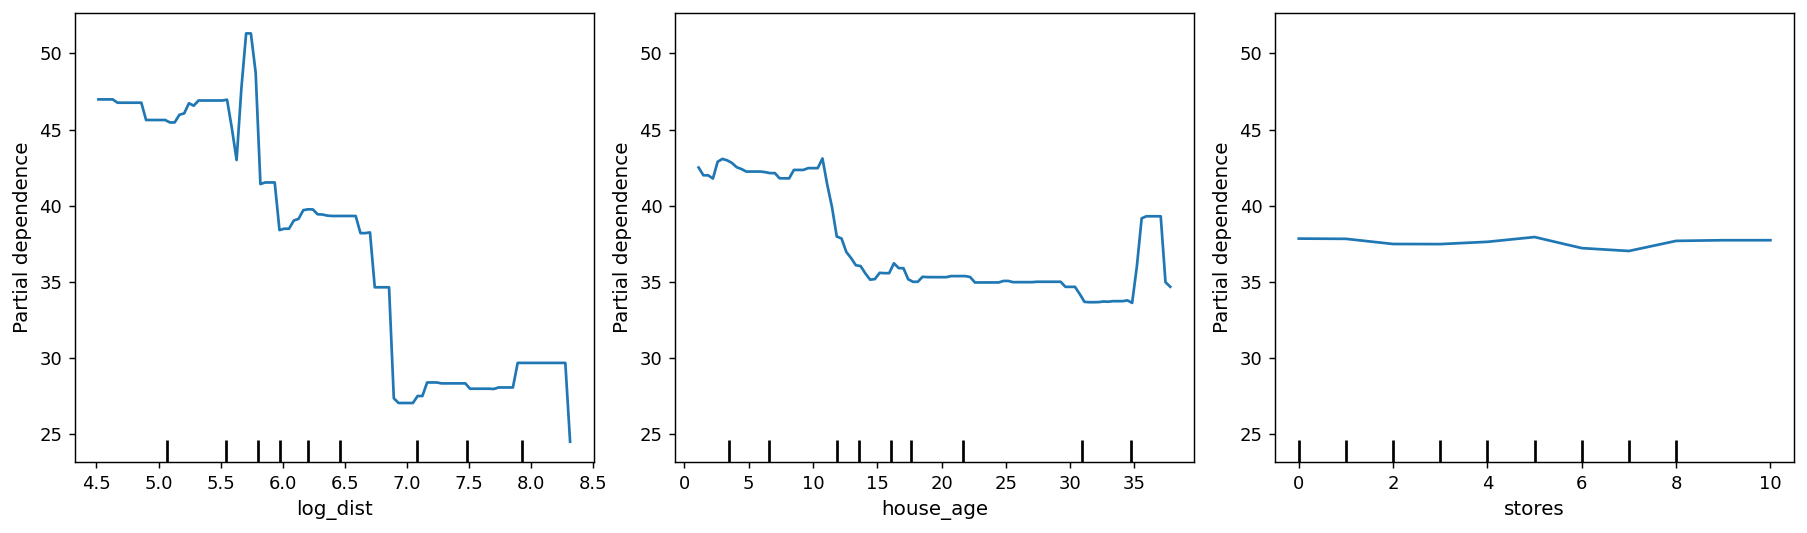

In [ ]:
rf_fit = clone(rf_model).fit(X_eng, y)
gbr_fit = clone(gbr_model).fit(X_eng, y)

perm_rf = permutation_importance(rf_fit, X_eng, y, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm_gbr = permutation_importance(gbr_fit, X_eng, y, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)

imp_rf = pd.DataFrame({"feature": X_eng.columns, "importance_mean": perm_rf.importances_mean, "importance_sd": perm_rf.importances_std, "model": "Random_forest"})
imp_gbr = pd.DataFrame({"feature": X_eng.columns, "importance_mean": perm_gbr.importances_mean, "importance_sd": perm_gbr.importances_std, "model": "Gradient_boosting"})
importance_df = pd.concat([imp_rf, imp_gbr], ignore_index=True).sort_values(["model", "importance_mean"], ascending=[True, False])
display(importance_df.head(20)); export_table(importance_df, "permutation_importance", index=False)

plot_df = imp_gbr.sort_values("importance_mean", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_sd"])
ax.set_title("Permutation importance (Gradient boosting)"); ax.set_xlabel("Mean drop in score after permutation")
plt.tight_layout(); savefig("fig10_permutation_importance_gbr"); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
PartialDependenceDisplay.from_estimator(gbr_fit, X_eng, features=["log_dist","house_age","stores"], ax=axes)
plt.tight_layout(); savefig("fig11_partial_dependence_gbr"); plt.show()

,price_bin,mae_mean,mae_median,count,group_var,model,distance_bin,geo_cluster
0,Low price,6.879358,6.590896,141,price_bin,OLS_baseline,NaN,NaN
1,Mid price,4.285067,3.651504,136,price_bin,OLS_baseline,NaN,NaN
2,High price,7.794515,5.382492,137,price_bin,OLS_baseline,NaN,NaN
3,Low price,4.884613,4.051763,141,price_bin,OLS_engineered,NaN,NaN
4,Mid price,4.338598,3.576029,136,price_bin,OLS_engineered,NaN,NaN
5,High price,6.776612,4.486193,137,price_bin,OLS_engineered,NaN,NaN
6,Low price,3.775181,2.834905,141,price_bin,Random_forest,NaN,NaN
7,Mid price,4.351599,3.373159,136,price_bin,Random_forest,NaN,NaN
8,High price,6.274813,4.119404,137,price_bin,Random_forest,NaN,NaN
9,Low price,3.695845,2.460137,141,price_bin,Gradient_boosting,NaN,NaN


Saved table -> /content/real_estate_project_outputs/latex_tables/subgroup_error_analysis.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/subgroup_error_analysis.tex
Saved figure -> /content/real_estate_project_outputs/latex_figures/fig12_error_by_price_tier.png


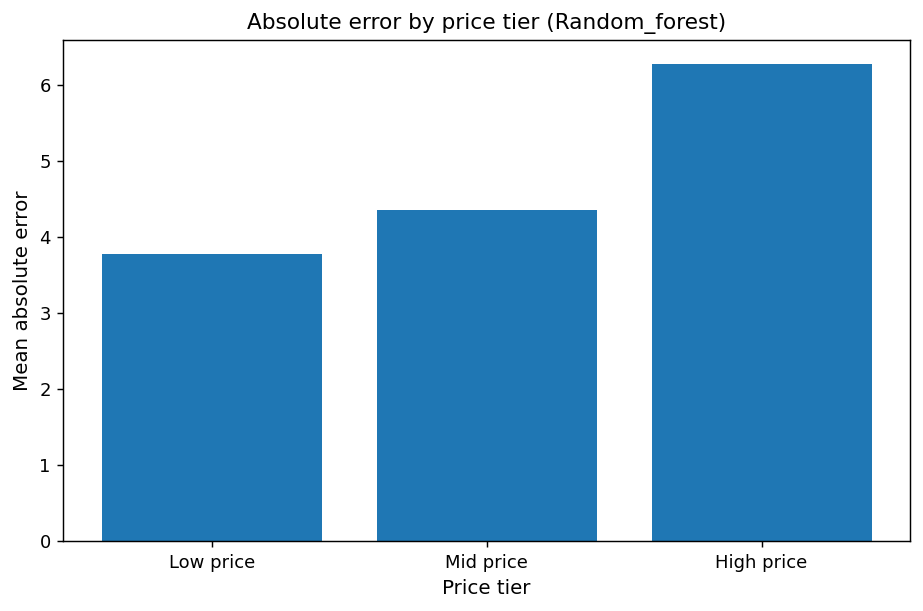

Saved figure -> /content/real_estate_project_outputs/latex_figures/fig13_spatial_error_map.png


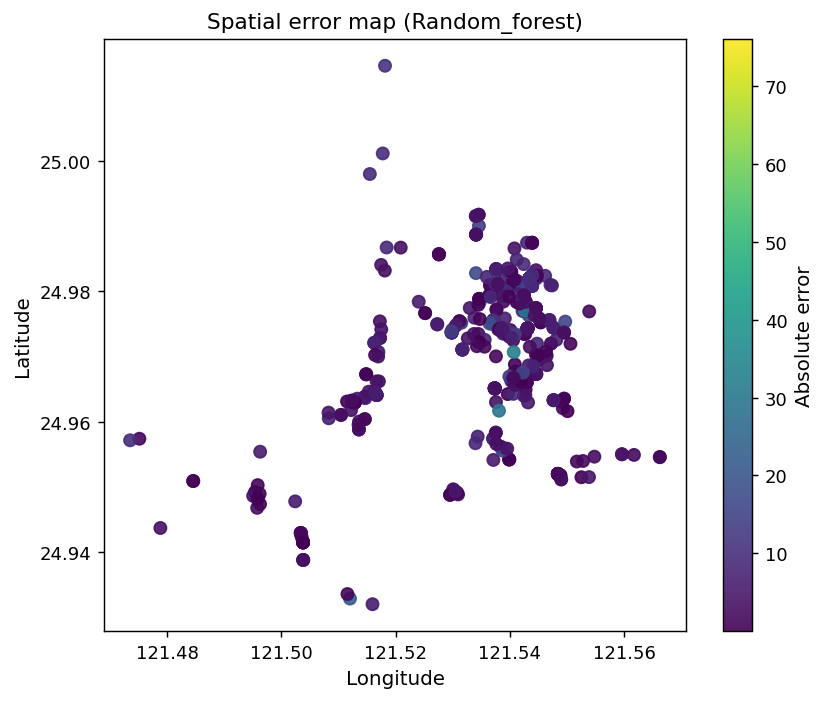

In [ ]:
oof_df["price_bin"] = pd.qcut(oof_df["price"], q=3, labels=["Low price","Mid price","High price"])
oof_df["distance_bin"] = pd.qcut(oof_df["distance_mrt"], q=3, labels=["Near MRT","Mid distance","Far from MRT"])

subgroup_rows = []
for group_var in ["price_bin", "distance_bin", "geo_cluster"]:
    for model_name in selected_oof.keys():
        grouped = oof_df.groupby(group_var)[f"abs_err_{model_name}"].agg(["mean","median","count"]).reset_index()
        grouped["group_var"] = group_var; grouped["model"] = model_name
        subgroup_rows.append(grouped)
subgroup_error = pd.concat(subgroup_rows, ignore_index=True).rename(columns={"mean":"mae_mean","median":"mae_median"})
display(subgroup_error.head(20)); export_table(subgroup_error, "subgroup_error_analysis", index=False)

best_oof_model = oof_metrics.iloc[0]["model"]
plot_data = subgroup_error.query("group_var == 'price_bin' and model == @best_oof_model").copy()
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.bar(plot_data.iloc[:, 0].astype(str), plot_data["mae_mean"])
ax.set_title(f"Absolute error by price tier ({best_oof_model})"); ax.set_xlabel("Price tier"); ax.set_ylabel("Mean absolute error")
plt.tight_layout(); savefig("fig12_error_by_price_tier"); plt.show()

fig, ax = plt.subplots(figsize=(6.6, 5.5))
sc = ax.scatter(oof_df["longitude"], oof_df["latitude"], c=oof_df[f"abs_err_{best_oof_model}"], s=45, alpha=0.9)
ax.set_title(f"Spatial error map ({best_oof_model})"); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax).set_label("Absolute error")
plt.tight_layout(); savefig("fig13_spatial_error_map"); plt.show()

In [ ]:
robustness_rows = [
    {"model":"OLS_raw_engineered", "response":"price", "R2":ols_raw.rsquared, "Adj_R2":ols_raw.rsquared_adj, "AIC":ols_raw.aic, "BIC":ols_raw.bic},
    {"model":"OLS_log_engineered", "response":"log_price", "R2":ols_log.rsquared, "Adj_R2":ols_log.rsquared_adj, "AIC":ols_log.aic, "BIC":ols_log.bic},
]
keep_mask = influence_df["cooks_d"] <= cook_threshold
work_sens = work.loc[keep_mask].copy()
ols_raw_sens = smf.ols(formula_raw, data=work_sens).fit()
robustness_rows.append({"model":"OLS_raw_engineered_no_high_cook", "response":"price", "R2":ols_raw_sens.rsquared, "Adj_R2":ols_raw_sens.rsquared_adj, "AIC":ols_raw_sens.aic, "BIC":ols_raw_sens.bic})
robustness_df = pd.DataFrame(robustness_rows).round(4)
display(robustness_df); export_table(robustness_df, "robustness_checks", index=False)

coef_compare = (
    coef_raw[["term","Coef.","P>|t|"]].rename(columns={"Coef.":"coef_full","P>|t|":"p_full"})
    .merge(
        ols_raw_sens.summary2().tables[1].reset_index().rename(columns={"index":"term","Coef.":"coef_sensitivity","P>|t|":"p_sensitivity"})[["term","coef_sensitivity","p_sensitivity"]],
        on="term", how="outer"
    )
)
display(coef_compare); export_table(coef_compare, "coefficient_sensitivity_comparison", index=False)

best_cv = cv_results.iloc[0]; second_cv = cv_results.iloc[1]
narrative_lines = [
    f"Sample size: {len(work)} observations.",
    f"Best CV model by RMSE: {best_cv['model']} (RMSE={best_cv['rmse_mean']:.3f}, R^2={best_cv['r2_mean']:.3f}).",
    f"Second-best CV model: {second_cv['model']} (RMSE={second_cv['rmse_mean']:.3f}, R^2={second_cv['r2_mean']:.3f}).",
    f"Engineered OLS on raw price: R^2={ols_raw.rsquared:.3f}, adjusted R^2={ols_raw.rsquared_adj:.3f}.",
    f"Engineered OLS on log(price): R^2={ols_log.rsquared:.3f}, adjusted R^2={ols_log.rsquared_adj:.3f}.",
    f"High-influence observations with Cook's D > 4/n: {high_influence.shape[0]}."
]
narrative_text = "\n".join("- " + line for line in narrative_lines)
print(narrative_text)
(TXT_DIR / "auto_narrative_notes.txt").write_text(narrative_text, encoding="utf-8")

,model,response,R2,Adj_R2,AIC,BIC
0,OLS_raw_engineered,price,0.6872,0.6810,2872.2994,2908.5322
1,OLS_log_engineered,log_price,0.7413,0.7362,-142.3087,-106.0759
2,OLS_raw_engineered_no_high_cook,price,0.8336,0.8302,2390.8096,2426.5279


Saved table -> /content/real_estate_project_outputs/latex_tables/robustness_checks.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/robustness_checks.tex


,term,coef_full,p_full,coef_sensitivity,p_sensitivity
0,Intercept,3.040379e+07,8.188443e-06,3.026723e+07,2.531346e-10
1,age_sq,1.676469e-02,3.158335e-07,1.102519e-02,2.702064e-06
2,house_age,-9.161911e-01,2.841880e-11,-7.416139e-01,3.199362e-14
3,lat_lon,1.003178e+04,8.062943e-06,9.985023e+03,2.474019e-10
4,latitude,-1.218857e+06,8.101212e-06,-1.213190e+06,2.496350e-10
5,log_dist,-5.790619e+00,7.252342e-21,-6.268532e+00,1.714533e-40
6,longitude,-2.503487e+05,8.076910e-06,-2.491864e+05,2.478930e-10
7,stores,2.126878e-01,2.546056e-01,2.024974e-01,1.183681e-01
8,transaction_date,6.730403e+00,1.078768e-06,4.590577e+00,1.004765e-06


Saved table -> /content/real_estate_project_outputs/latex_tables/coefficient_sensitivity_comparison.csv
Saved table -> /content/real_estate_project_outputs/latex_tables/coefficient_sensitivity_comparison.tex
- Sample size: 414 observations.
- Best CV model by RMSE: Random_forest (RMSE=7.401, R^2=0.698).
- Second-best CV model: Gradient_boosting (RMSE=7.700, R^2=0.674).
- Engineered OLS on raw price: R^2=0.687, adjusted R^2=0.681.
- Engineered OLS on log(price): R^2=0.741, adjusted R^2=0.736.
- High-influence observations with Cook's D > 4/n: 23.


343